In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [2]:
ds1 = xr.open_dataset("/Users/madisonrichardson/netpp/data/snpp/matrix/psi/netpp_psi_snpp_modis.nc")
ds2 = xr.open_dataset("/Users/madisonrichardson/netpp/data/noaa20/matrix/psi/netpp_psi_noaa20_modis.nc")

In [3]:
def plot_psi_timeseries(my_date1, my_date2, psi_mean1, psi_mean2, label1="Dataset 1", label2="Dataset 2"):
    """
    Plot a timeseries of two monthly unbiased relative difference (psi) values.

    Args:
        my_date (array-like): Dates for x-axis.
        psi_mean1 (array-like): First psi timeseries.
        psi_mean2 (array-like): Second psi timeseries.
        label1 (str): Legend label for first timeseries.
        label2 (str): Legend label for second timeseries.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot both lines
    plt.plot(my_date1, psi_mean1, color="black", linewidth=3, label=label1)
    plt.plot(my_date2, psi_mean2, color="gray", linewidth=3, label=label2)
    
    # Reference lines
    plt.axhline(0, color="gray", linewidth=0.5)
    plt.axhline(0.05, color="red", linestyle=":", linewidth=2)
    plt.axhline(-0.05, color="red", linestyle=":", linewidth=2)
    
    # Axes settings
    plt.ylim(-0.2, 0.2)
    #plt.title("Timeseries: Monthly Means of Unbiased Relative Difference", fontsize=24)

    # Date formatting
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=14)

    # x and y labels
    plt.xlabel("Year", fontsize=18)
    plt.ylabel("Unbiased Relative Difference (ψ)", fontsize=18)


    # Grid and legend
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig("greyscale_psi_timeseries.png", dpi=300, bbox_inches="tight")
    plt.show()


In [4]:
da1 = ds1.psi
da2 = ds2.psi

In [5]:
psi_mean1 = da1.mean(dim=["latitude", "longitude"], skipna=True)
psi_mean2 = da2.mean(dim=["latitude", "longitude"], skipna=True)

# Align the dates
my_date1 = pd.to_datetime(da1.time.values).map(lambda x: x.replace(day=16))
my_date2 = pd.to_datetime(da2.time.values).map(lambda x: x.replace(day=16))

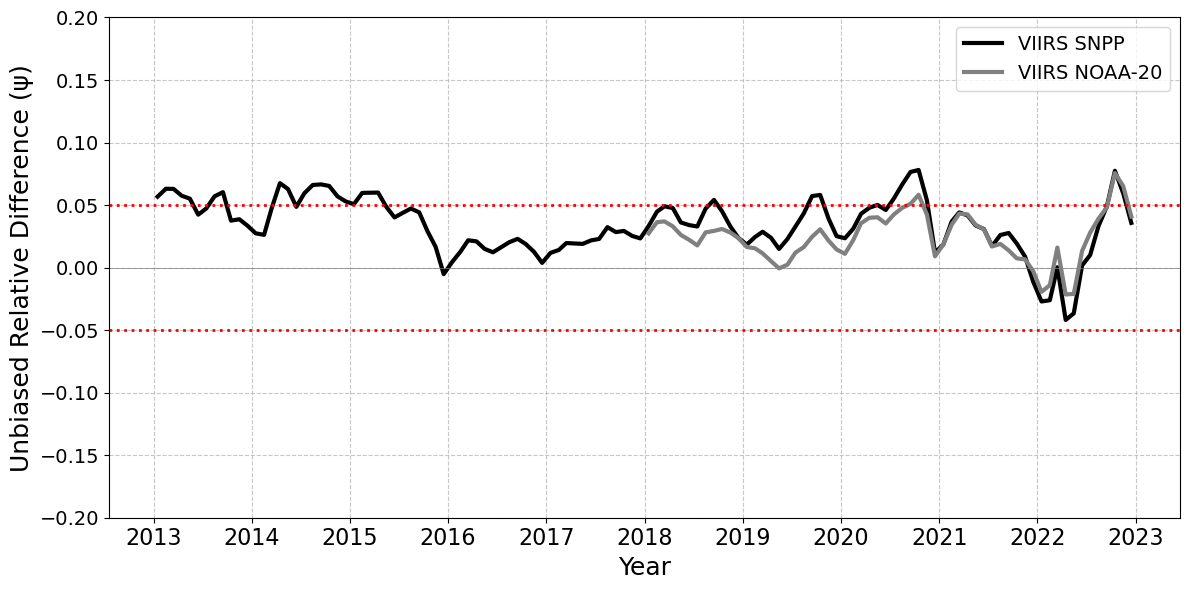

In [6]:

# Call the updated function
plot_psi_timeseries(my_date1, my_date2, psi_mean1, psi_mean2, label1="VIIRS SNPP", label2="VIIRS NOAA-20")